# **Анализ данных**

In [46]:
# Импортируем библиотеки (это готовые инструменты для работы с данными)
import pandas as pd        # для работы с таблицами
import matplotlib.pyplot as plt   # для создания графиков
import seaborn as sns      # для графиков
import numpy as np         # для математических операций

# Настройка для красивого отображения графиков
plt.rcParams['figure.figsize'] = (10, 6)  # размер графиков
plt.rcParams['font.size'] = 10            # размер шрифта
sns.set_style("whitegrid")                # стиль графиков

#ЗАГРУЗКА ДАННЫХ

# Загружаем CSV файл в переменную df
df = pd.read_csv("hr.csv")

# Берем только первые 1000 строк
df = df.head(1000)

print("\nПервые 5 строк данных:")

# Выводим таблицу
display(df.head())




Первые 5 строк данных:


,Unnamed: 0,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Location,Performance_Rating,Experience_Years,Status,Work_Mode,Salary_INR
0,0,EMP0000001,Joshua Nguyen,IT,Software Engineer,2011-08-10,"Isaacland, Denmark",5,14,Resigned,On-site,1585363
1,1,EMP0000002,Julie Williams,Marketing,SEO Specialist,2018-03-02,"Anthonyside, Costa Rica",2,7,Active,On-site,847686
2,2,EMP0000003,Alyssa Martinez,HR,HR Manager,2023-03-20,"Port Christinaport, Saudi Arabia",1,2,Active,On-site,1430084
3,3,EMP0000004,Nicholas Valdez,IT,Software Engineer,2023-10-12,"Port Shelbychester, Antigua and Barbuda",1,1,Active,On-site,990689
4,4,EMP0000005,Joel Hendricks,Operations,Logistics Coordinator,2024-12-09,"Lake Kimberly, Palestinian Territory",5,0,Active,On-site,535082


In [23]:
#БАЗОВЫЕ МЕТРИКИ
print("БАЗОВЫЕ МЕТРИКИ")

# Считаем метрики
total_employees = len(df)
avg_salary = df['Salary_INR'].mean()
avg_performance = df['Performance_Rating'].mean()
avg_experience = df['Experience_Years'].mean()

# Создаём таблицу
metrics_df = pd.DataFrame({
    'Метрика': [
        'Общее количество сотрудников',
        'Средняя зарплата',
        'Средняя оценка производительности',
        'Средний опыт работы'
    ],
    'Значение': [
        total_employees,
        f"{avg_salary:.2f} INR",
        f"{avg_performance:.2f}",
        f"{avg_experience:.2f} лет"
    ]
})

display(metrics_df.style.set_properties(**{'text-align': 'left'})
                .hide(axis='index'))

БАЗОВЫЕ МЕТРИКИ


Метрика,Значение
Общее количество сотрудников,1000
Средняя зарплата,907950.38 INR
Средняя оценка производительности,2.97
Средний опыт работы,5.10 лет


КОРРЕЛЯЦИОННЫЙ АНАЛИЗ

Матрица корреляции:


,Performance_Rating,Experience_Years,Salary_INR
Performance_Rating,1.00,-0.03,-0.05
Experience_Years,-0.03,1.00,0.02
Salary_INR,-0.05,0.02,1.00


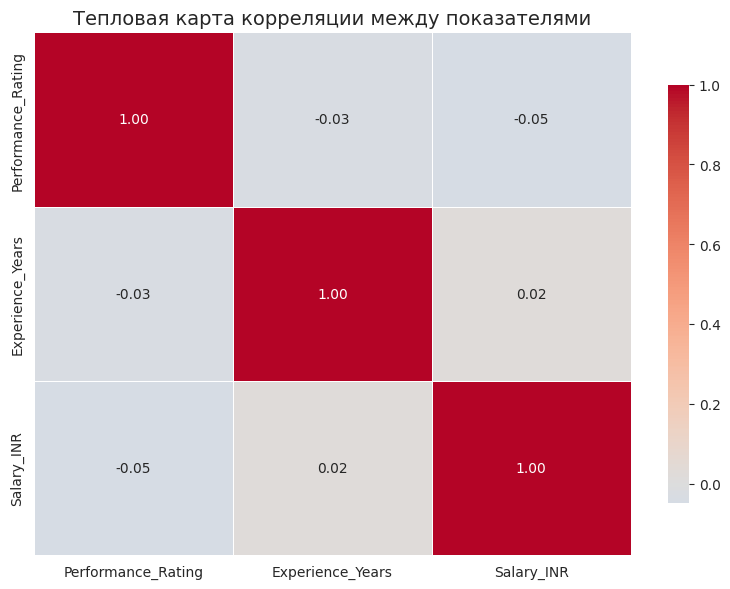

In [24]:
#КОРРЕЛЯЦИОННЫЙ АНАЛИЗ
print("КОРРЕЛЯЦИОННЫЙ АНАЛИЗ")

# Выбираем только числовые колонки для корреляции
numeric_columns = ['Performance_Rating', 'Experience_Years', 'Salary_INR']

# Считаем корреляцию
correlation_matrix = df[numeric_columns].corr()

print("\nМатрица корреляции:")
display(correlation_matrix.round(2))  # округляем до 2 знаков для читаемости

# Создаём тепловую карту корреляций
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f',
    linewidths=0.5,          # линии между ячейками для лучшей читаемости
    cbar_kws={'shrink': 0.8} # чуть уменьшаем цветовую шкалу
)
plt.title('Тепловая карта корреляции между показателями', fontsize=14)
plt.tight_layout()
plt.savefig('01_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

РАСПРЕДЕЛЕНИЕ ПО ДЕПАРТАМЕНТАМ

Таблица распределения:


,Количество сотрудников,Доля (%)
Department,,
IT,299,29.9
Sales,205,20.5
Operations,158,15.8
Marketing,115,11.5
Finance,88,8.8
HR,84,8.4
R&D,51,5.1


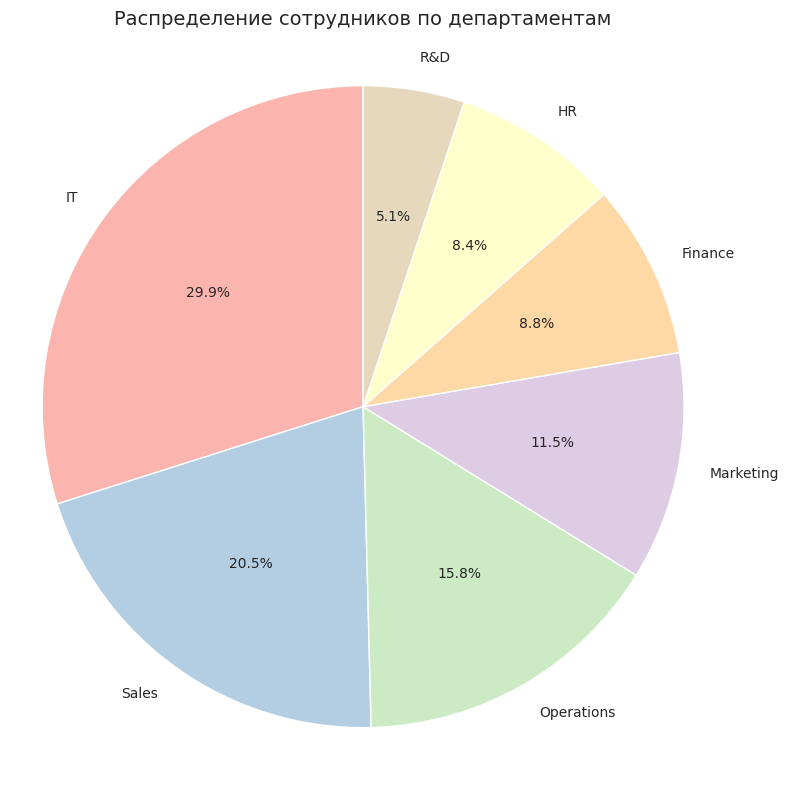

In [25]:
#РАСПРЕДЕЛЕНИЕ ПО ДЕПАРТАМЕНТАМ

print("РАСПРЕДЕЛЕНИЕ ПО ДЕПАРТАМЕНТАМ")

# Считаем количество сотрудников в каждом департаменте
dept_counts = df['Department'].value_counts()

# Преобразуем в DataFrame для красивого отображения
dept_table = dept_counts.to_frame(name='Количество сотрудников')
dept_table['Доля (%)'] = (dept_counts / dept_counts.sum() * 100).round(1)

print("\nТаблица распределения:")
display(dept_table)

# Круговая диаграмма (визуализация)
plt.figure(figsize=(8, 8))
plt.pie(
    dept_counts.values,
    labels=dept_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=plt.cm.Pastel1.colors  # мягкие цвета для лучшей читаемости
)
plt.title('Распределение сотрудников по департаментам', fontsize=14)
plt.axis('equal')
plt.tight_layout()
plt.savefig('02_department_pie.png', dpi=300, bbox_inches='tight')
plt.show()


Таблица средних зарплат:


,Средняя зарплата (INR)
Department,
HR,746725.60
Marketing,747229.49
Operations,784242.70
Sales,788520.32
R&D,805980.69
Finance,1044539.93
IT,1139506.70


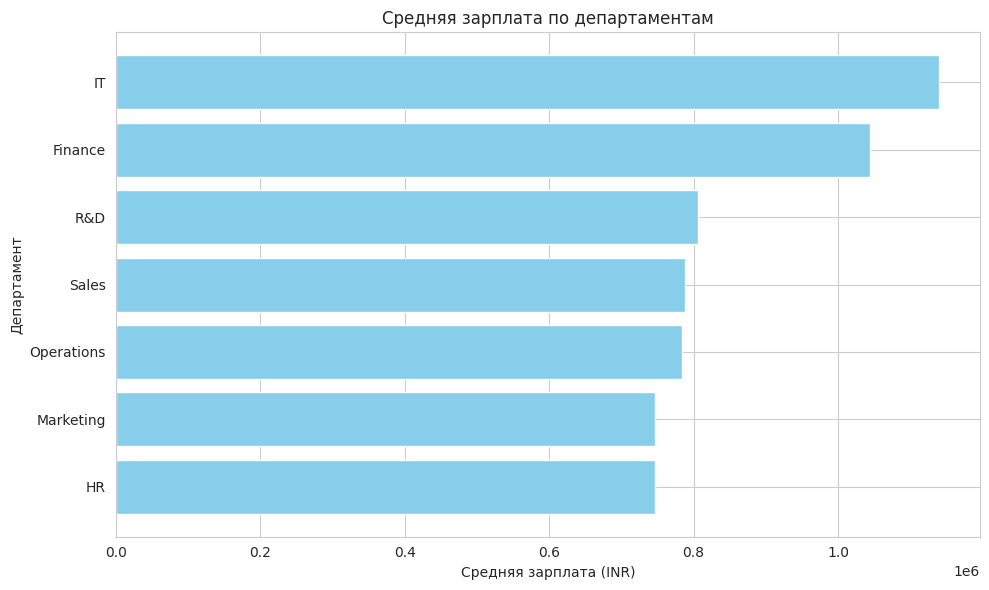

In [30]:
#СРЕДНЯЯ ЗАРПЛАТА ПО ДЕПАРТАМЕНТАМ

# Группируем данные по департаментам и считаем среднюю зарплату
avg_salary_by_dept = df.groupby('Department')['Salary_INR'].mean()

# Сортируем по убыванию
avg_salary_by_dept = avg_salary_by_dept.sort_values()

# Преобразуем в DataFrame для вывода через display
salary_table = avg_salary_by_dept.to_frame(name='Средняя зарплата (INR)')
salary_table['Средняя зарплата (INR)'] = salary_table['Средняя зарплата (INR)'].round(2)

print("\nТаблица средних зарплат:")
display(salary_table)

# Создаем горизонтальную столбчатую диаграмму — без изменений по сравнению с оригиналом
plt.figure(figsize=(10, 6))
plt.barh(avg_salary_by_dept.index,  # названия департаментов
         avg_salary_by_dept.values,  # значения зарплат
         color='skyblue')
plt.xlabel('Средняя зарплата (INR)')
plt.ylabel('Департамент')
plt.title('Средняя зарплата по департаментам')
plt.tight_layout()
plt.savefig('03_avg_salary_by_dept.png')
plt.show()


Таблица средних оценок:


,Средняя оценка производительности
Department,
HR,2.76
Finance,2.90
Sales,2.94
R&D,3.00
Operations,3.01
IT,3.01
Marketing,3.09


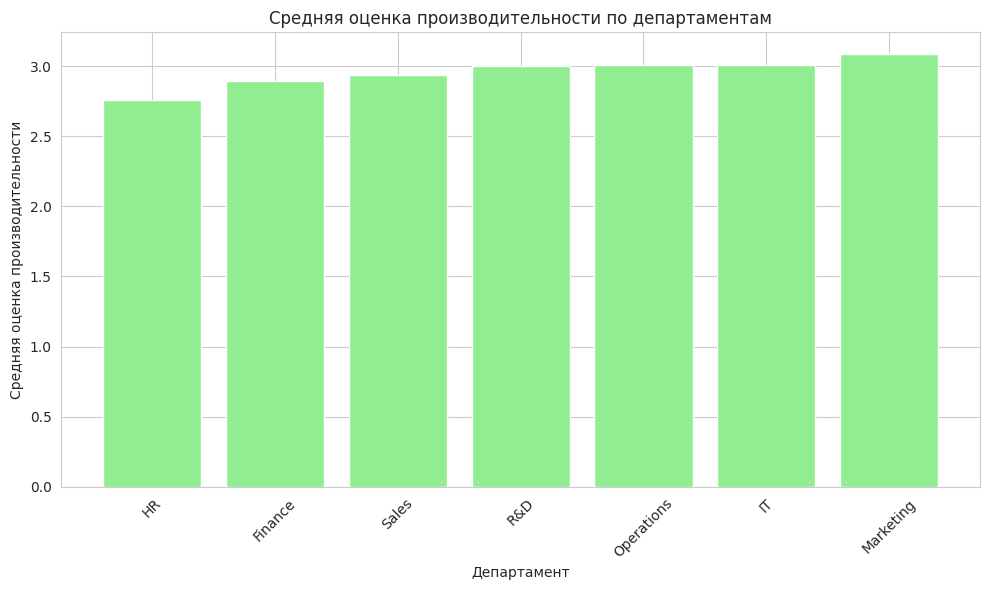

In [29]:
#СРЕДНЯЯ ОЦЕНКА ПРОИЗВОДИТЕЛЬНОСТИ ПО ДЕПАРТАМЕНТАМ

# Считаем средний рейтинг по департаментам
avg_performance_by_dept = df.groupby('Department')['Performance_Rating'].mean()
avg_performance_by_dept = avg_performance_by_dept.sort_values()

# Преобразуем в DataFrame и выводим через display
performance_table = avg_performance_by_dept.to_frame(name='Средняя оценка производительности')
performance_table['Средняя оценка производительности'] = performance_table['Средняя оценка производительности'].round(2)

print("\nТаблица средних оценок:")
display(performance_table)

# Создаем столбчатую диаграмму — без изменений по сравнению с оригиналом
plt.figure(figsize=(10, 6))
plt.bar(avg_performance_by_dept.index,  # департаменты
        avg_performance_by_dept.values,  # рейтинги
        color='lightgreen')
plt.xlabel('Департамент')
plt.ylabel('Средняя оценка производительности')
plt.title('Средняя оценка производительности по департаментам')
plt.xticks(rotation=45)  # поворачиваем названия
plt.tight_layout()
plt.savefig('04_avg_performance_by_dept.png')
plt.show()

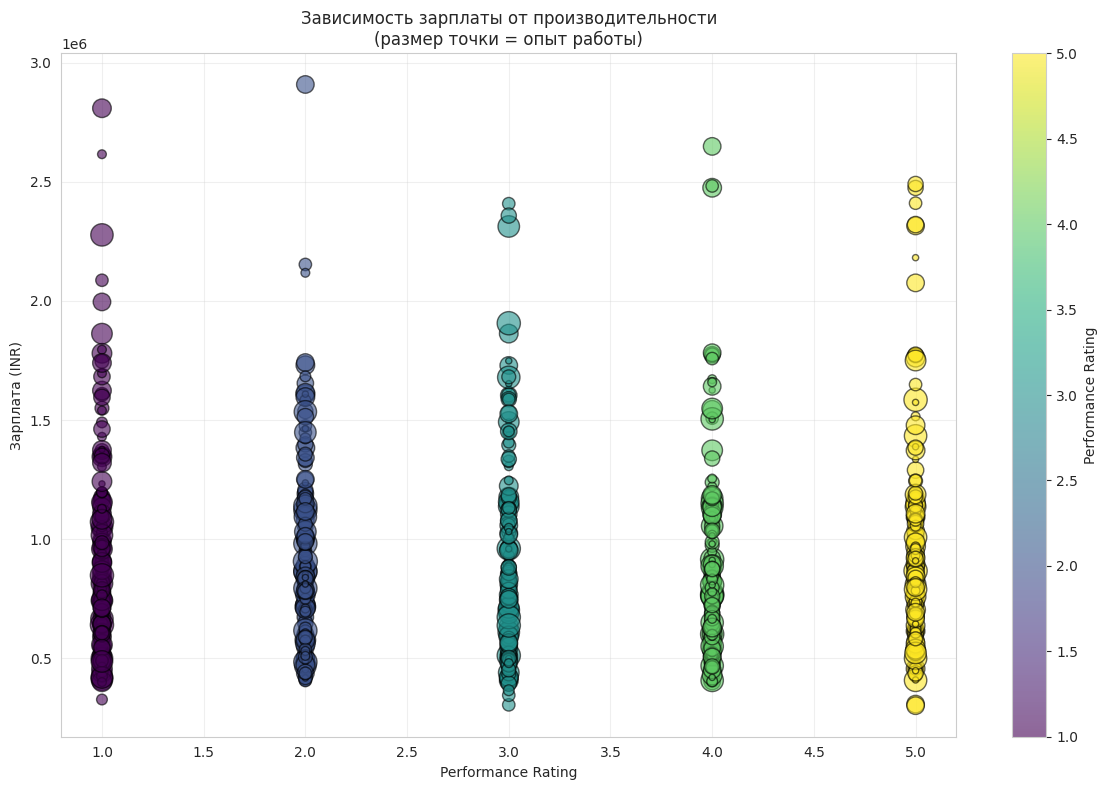

In [31]:
#Диаграмма рассения - PERFORMANCE VS SALARY

# Создаем диаграмму рассеяния
plt.figure(figsize=(12, 8))

# Создаем scatter plot с размером точек по опыту
scatter = plt.scatter(df['Performance_Rating'],  # ось X
                     df['Salary_INR'],  # ось Y
                     s=df['Experience_Years'] * 20,  # размер точек
                     c=df['Performance_Rating'],  # цвет по рейтингу
                     cmap='viridis',  # цветовая схема
                     alpha=0.6,  # прозрачность
                     edgecolors='black')

plt.xlabel('Performance Rating')
plt.ylabel('Зарплата (INR)')
plt.title('Зависимость зарплаты от производительности\n(размер точки = опыт работы)')
plt.colorbar(scatter, label='Performance Rating')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('05_performance_vs_salary_scatter.png')
plt.show()




 Распределение по рейтингам:


,Количество сотрудников
Performance_Rating,
1,211
2,200
3,194
4,196
5,199


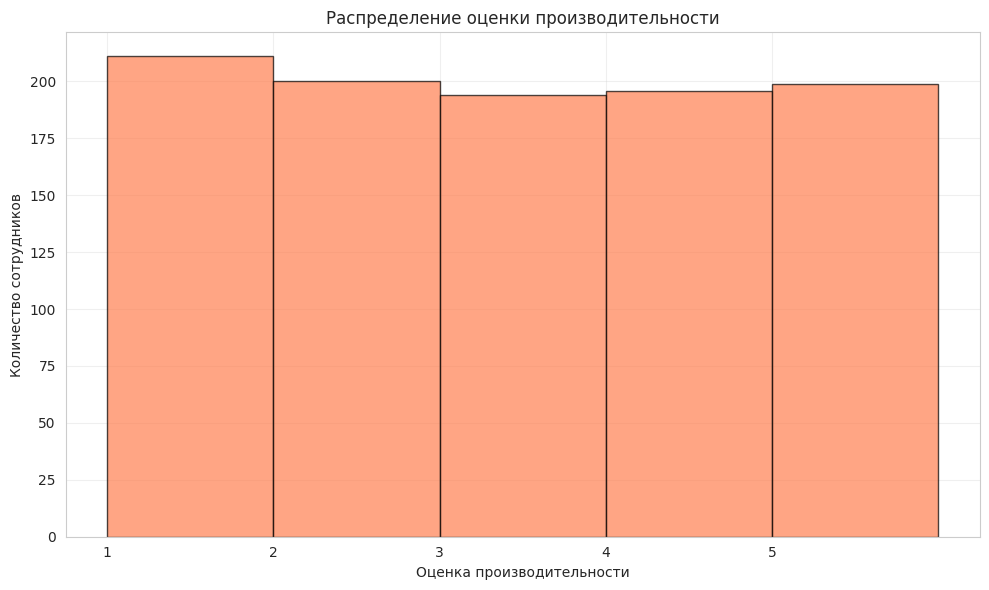

In [45]:
#ГИСТОГРАММА ОЦЕНКИ ПРОИЗВОДИТЕЛЬНОСТИ (PERFORMANCE RATING)

# Считаем количество каждого рейтинга
rating_counts = df['Performance_Rating'].value_counts().sort_index()

# Преобразуем в DataFrame для корректного display (без Name/dtype)
rating_table = rating_counts.to_frame(name='Количество сотрудников')

print("\n Распределение по рейтингам:")
display(rating_table)

# Создаем гистограмму — без изменений по сравнению с оригиналом
plt.figure(figsize=(10, 6))
plt.hist(df['Performance_Rating'],
         bins=range(1, 7),  # от 1 до 6
         color='coral',
         edgecolor='black',
         alpha=0.7)
plt.xlabel('Оценка производительности')
plt.ylabel('Количество сотрудников')
plt.title('Распределение оценки производительности')
plt.xticks(range(1, 6))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('06_performance_histogram.png')
plt.show()

<Figure size 1200x600 with 0 Axes>

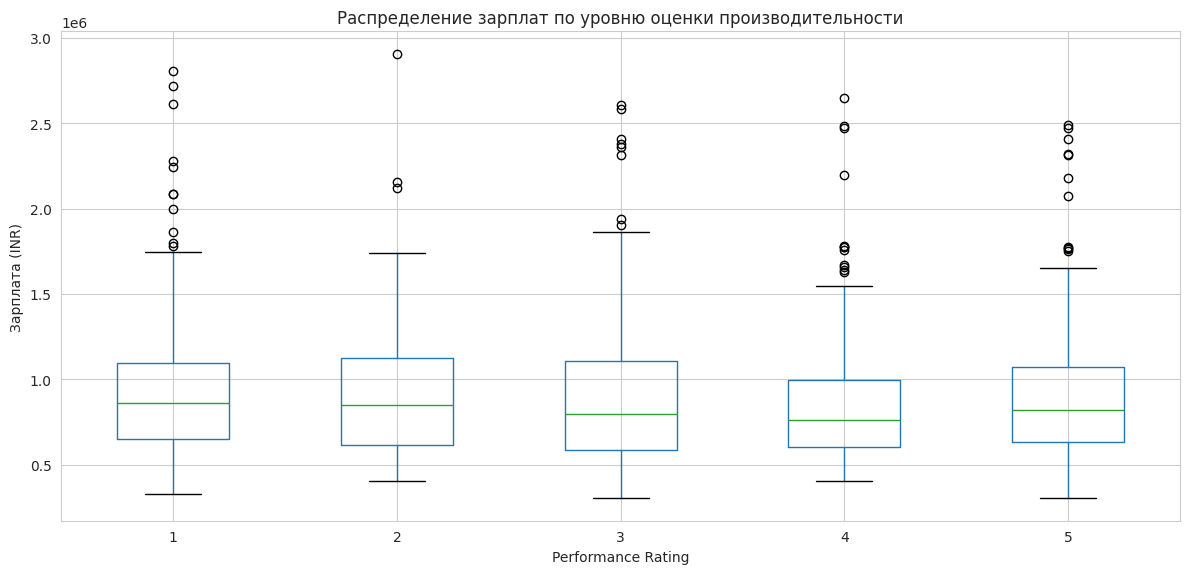

In [34]:
#BOX PLOT ЗАРПЛАТ ПО PERFORMANCE RATING

# Создаем box plot
plt.figure(figsize=(12, 6))
df.boxplot(column='Salary_INR',  # что анализируем
           by='Performance_Rating',  # по каким группам
           figsize=(12, 6))
plt.xlabel('Performance Rating')
plt.ylabel('Зарплата (INR)')
plt.title('Распределение зарплат по уровню оценки производительности')
plt.suptitle('')
plt.tight_layout()
plt.savefig('07_salary_boxplot_by_performance.png')
plt.show()


In [44]:
# Получаем статистику по всем числовым колонкам
statistics = df[numeric_columns].describe()
print("\n Статистика по числовым показателям:")
display(statistics)

# Создаем таблицу с детальной статистикой по зарплате
print("\n Статистика по зарплате")

salary_stats = {
    'Минимальная зарплата': df['Salary_INR'].min(),
    'Максимальная зарплата': df['Salary_INR'].max(),
    'Средняя зарплата': df['Salary_INR'].mean(),
    'Медиана зарплаты': df['Salary_INR'].median(),
    'Стандартное отклонение': df['Salary_INR'].std(),
    '25-й перцентиль': df['Salary_INR'].quantile(0.25),
    '75-й перцентиль': df['Salary_INR'].quantile(0.75)
}

# Преобразуем в DataFrame для красивого отображения
salary_stats_df = pd.DataFrame.from_dict(salary_stats, orient='index', columns=['Значение (INR)'])
salary_stats_df.index.name = 'Показатель'
salary_stats_df['Значение (INR)'] = salary_stats_df['Значение (INR)'].round(2)

display(salary_stats_df)


 Статистика по числовым показателям:


,Performance_Rating,Experience_Years,Salary_INR
count,1000.000000,1000.000000,1.000000e+03
mean,2.972000,5.098000,9.079504e+05
std,1.427324,3.634227,4.121182e+05
min,1.000000,0.000000,3.019570e+05
25%,2.000000,2.000000,6.159705e+05
50%,3.000000,5.000000,8.222450e+05
75%,4.000000,8.000000,1.081183e+06
max,5.000000,15.000000,2.908256e+06



 Статистика по зарплате


,Значение (INR)
Показатель,
Минимальная зарплата,301957.00
Максимальная зарплата,2908256.00
Средняя зарплата,907950.38
Медиана зарплаты,822245.00
Стандартное отклонение,412118.21
25-й перцентиль,615970.50
75-й перцентиль,1081183.25


In [36]:
#СВОДНАЯ ТАБЛИЦА ПО ДЕПАРТАМЕНТАМ
print("СВОДНАЯ ТАБЛИЦА ПО ДЕПАРТАМЕНТАМ")

# Создаем сводную таблицу
summary_by_dept = df.groupby('Department').agg({
    'Employee_ID': 'count',        # количество сотрудников
    'Salary_INR': 'mean',          # средняя зарплата
    'Performance_Rating': 'mean',  # средний рейтинг
    'Experience_Years': 'mean'     # средний опыт
}).round(2)

# Переименовываем колонки
summary_by_dept.columns = ['Количество', 'Средняя зарплата (INR)',
                            'Средний рейтинг', 'Средний опыт (лет)']

# Выводим через display
display(summary_by_dept)

# Сохраняем таблицу в CSV
summary_by_dept.to_csv('department_summary.csv', encoding='utf-8-sig')
# print("\nСводная таблица сохранена в файл 'department_summary.csv'")


СВОДНАЯ ТАБЛИЦА ПО ДЕПАРТАМЕНТАМ


,Количество,Средняя зарплата (INR),Средний рейтинг,Средний опыт (лет)
Department,,,,
Finance,88,1044539.93,2.90,5.73
HR,84,746725.60,2.76,4.63
IT,299,1139506.70,3.01,4.75
Marketing,115,747229.49,3.09,5.10
Operations,158,784242.70,3.01,5.20
R&D,51,805980.69,3.00,5.47
Sales,205,788520.32,2.94,5.37


# **Сравнительный анализ**

In [42]:
import pandas as pd
from IPython.display import display

#Загружаем данные (только первые 1000 строк)
df = pd.read_csv('hr.csv', nrows=1000)

#Проверка данных
print("Первые 5 строк данных:")
display(df.head())

# 1. БАЗОВАЯ ФОРМУЛА
department_coef = {
    'Marketing': 1.2,
    'IT': 1.15,
    'Operations': 1.0,
    'HR': 1.05
}

def get_dept_coef(dept):
    return department_coef.get(dept, 1.0)

df['Performance_Coefficient'] = df['Performance_Rating'] / 5
df['Department_Coefficient'] = df['Department'].apply(get_dept_coef)
df['Bonus_Basic'] = df['Salary_INR'] * df['Performance_Coefficient'] * df['Department_Coefficient']

# 2. ПРОГРЕССИВНАЯ ФОРМУЛА С ОПЫТОМ
df['Bonus_Progressive'] = df['Salary_INR'] * (0.05 * df['Performance_Rating'] + 0.02 * df['Experience_Years'])

# 3. ПОРОГОВАЯ СИСТЕМА
def calculate_threshold_bonus(row):
    rating = row['Performance_Rating']
    if rating >= 4:
        return row['Salary_INR'] * 0.20
    elif rating == 3:
        return row['Salary_INR'] * 0.10
    elif rating == 2:
        return row['Salary_INR'] * 0.05
    else:
        return 0

df['Bonus_Threshold'] = df.apply(calculate_threshold_bonus, axis=1)

# 4. МАТРИЧНАЯ СИСТЕМА
def calculate_matrix_bonus(row):
    rating = row['Performance_Rating']
    exp = row['Experience_Years']

    if rating <= 2:
        percent = 0.05 if exp <= 2 else (0.07 if exp <= 5 else 0.08)
    elif rating == 3:
        percent = 0.10 if exp <= 2 else (0.12 if exp <= 5 else 0.15)
    else:  # rating >= 4
        percent = 0.15 if exp <= 2 else (0.20 if exp <= 5 else 0.25)

    return row['Salary_INR'] * percent

df['Bonus_Matrix'] = df.apply(calculate_matrix_bonus, axis=1)

# ВЫБОР ИТОГОВОЙ ФОРМУЛЫ
df['Final_Bonus'] = df['Bonus_Basic']
df['Total_Salary_With_Bonus'] = df['Salary_INR'] + df['Final_Bonus']

# ИТОГОВАЯ ТАБЛИЦА
result_table = df[[
    'Department',
    'Full_Name',
    'Performance_Rating',
    'Salary_INR',
    'Final_Bonus',
    'Total_Salary_With_Bonus'
]].copy()

result_table.columns = [
    'Департамент',
    'Сотрудник',
    'Рейтинг KPI',
    'Базовая зарплата',
    'Премия',
    'Итоговая зарплата с премией'
]

result_table['Премия'] = result_table['Премия'].round(2)
result_table['Итоговая зарплата с премией'] = result_table['Итоговая зарплата с премией'].round(2)

#ВЫВОД ИТОГОВОЙ ТАБЛИЦЫ
print("\n ИТОГОВАЯ ТАБЛИЦА ПРЕМИРОВАНИЯ (первые 20 строк)")
display(result_table.head(20))

# СТАТИСТИКА ПО ДЕПАРТАМЕНТАМ
dept_summary = result_table.groupby('Департамент').agg({
    'Премия': 'sum',
    'Итоговая зарплата с премией': 'sum',
    'Сотрудник': 'count'
}).round(2)

dept_summary.columns = ['Общая сумма премий', 'Общая зарплата с премиями', 'Количество сотрудников']


print("\n СТАТИСТИКА ПО ДЕПАРТАМЕНТАМ")
display(dept_summary)

#ТОП-10 СОТРУДНИКОВ ПО ПРЕМИИ
top_10 = result_table.nlargest(10, 'Премия')


print("\n ТОП-10 СОТРУДНИКОВ ПО РАЗМЕРУ ПРЕМИИ")
display(top_10)

# СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
result_table.to_csv('bonus_results.csv', index=False, encoding='utf-8-sig')
dept_summary.to_csv('department_summary.csv', encoding='utf-8-sig')

Первые 5 строк данных:


,Unnamed: 0,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Location,Performance_Rating,Experience_Years,Status,Work_Mode,Salary_INR
0,0,EMP0000001,Joshua Nguyen,IT,Software Engineer,2011-08-10,"Isaacland, Denmark",5,14,Resigned,On-site,1585363
1,1,EMP0000002,Julie Williams,Marketing,SEO Specialist,2018-03-02,"Anthonyside, Costa Rica",2,7,Active,On-site,847686
2,2,EMP0000003,Alyssa Martinez,HR,HR Manager,2023-03-20,"Port Christinaport, Saudi Arabia",1,2,Active,On-site,1430084
3,3,EMP0000004,Nicholas Valdez,IT,Software Engineer,2023-10-12,"Port Shelbychester, Antigua and Barbuda",1,1,Active,On-site,990689
4,4,EMP0000005,Joel Hendricks,Operations,Logistics Coordinator,2024-12-09,"Lake Kimberly, Palestinian Territory",5,0,Active,On-site,535082



 ИТОГОВАЯ ТАБЛИЦА ПРЕМИРОВАНИЯ (первые 20 строк)


,Департамент,Сотрудник,Рейтинг KPI,Базовая зарплата,Премия,Итоговая зарплата с премией
0,IT,Joshua Nguyen,5,1585363,1823167.45,3408530.45
1,Marketing,Julie Williams,2,847686,406889.28,1254575.28
2,HR,Alyssa Martinez,1,1430084,300317.64,1730401.64
3,IT,Nicholas Valdez,1,990689,227858.47,1218547.47
4,Operations,Joel Hendricks,5,535082,535082.00,1070164.00
5,Operations,Jason Gardner,5,641393,641393.00,1282786.00
6,Finance,Julie Wright,2,1383891,553556.40,1937447.40
7,Sales,Scott Wilson,2,423091,169236.40,592327.40
8,Finance,Cathy Thompson,4,1138452,910761.60,2049213.60
9,IT,Maria Yu MD,4,1543102,1419653.84,2962755.84



 СТАТИСТИКА ПО ДЕПАРТАМЕНТАМ


,Общая сумма премий,Общая зарплата с премиями,Количество сотрудников
Департамент,,,
Finance,5.280240e+07,1.447219e+08,88
HR,3.511506e+07,9.784001e+07,84
IT,2.334334e+08,5.741459e+08,299
Marketing,6.431013e+07,1.502415e+08,115
Operations,7.307039e+07,1.969807e+08,158
R&D,2.365079e+07,6.475581e+07,51
Sales,9.445047e+07,2.560971e+08,205



 ТОП-10 СОТРУДНИКОВ ПО РАЗМЕРУ ПРЕМИИ


,Департамент,Сотрудник,Рейтинг KPI,Базовая зарплата,Премия,Итоговая зарплата с премией
975,IT,Robin Burke,5,2490721,2864329.15,5355050.15
171,IT,Tara Martinez,5,2474037,2845142.55,5319179.55
517,IT,Shawn Young,5,2410193,2771721.95,5181914.95
539,IT,Travis Scott,5,2314827,2662051.05,4976878.05
903,IT,Henry Lane,5,2181629,2508873.35,4690502.35
207,IT,Jose Baker,4,2648462,2436585.04,5085047.04
376,IT,Betty Henderson,5,2075810,2387181.50,4462991.50
737,Finance,Brittany Edwards,5,2320289,2320289.00,4640578.00
799,IT,David Rodriguez,4,2482486,2283887.12,4766373.12
244,IT,Terrance Curtis,5,1774843,2041069.45,3815912.45


# **Расчет премий**

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Загружаем данные (только первые 1000 строк)
df = pd.read_csv('hr.csv', nrows=1000)

print("Первые 5 строк данных:")
display(df.head())

# РАСЧЕТ ВСЕХ ФОРМУЛ

# 1. БАЗОВАЯ ФОРМУЛА
department_coef = {
    'Marketing': 1.2,
    'IT': 1.15,
    'Operations': 1.0,
    'HR': 1.05
}

def get_dept_coef(dept):
    return department_coef.get(dept, 1.0)

df['Performance_Coefficient'] = df['Performance_Rating'] / 5
df['Department_Coefficient'] = df['Department'].apply(get_dept_coef)
df['Bonus_1_Basic'] = df['Salary_INR'] * df['Performance_Coefficient'] * df['Department_Coefficient']

# 2. ПРОГРЕССИВНАЯ ФОРМУЛА С ОПЫТОМ
df['Bonus_2_Progressive'] = df['Salary_INR'] * (0.05 * df['Performance_Rating'] + 0.02 * df['Experience_Years'])

# 3. ПОРОГОВАЯ СИСТЕМА
def calculate_threshold_bonus(row):
    if row['Performance_Rating'] >= 4:
        return row['Salary_INR'] * 0.20
    elif row['Performance_Rating'] == 3:
        return row['Salary_INR'] * 0.10
    elif row['Performance_Rating'] == 2:
        return row['Salary_INR'] * 0.05
    else:
        return 0

df['Bonus_3_Threshold'] = df.apply(calculate_threshold_bonus, axis=1)

# 4. ФОРМУЛА С УЧЕТОМ СТАЖА
df['Bonus_4_Loyalty'] = df['Salary_INR'] * (df['Performance_Rating'] / 5) * (1 + df['Experience_Years'] * 0.03)

# 5. КОМБИНИРОВАННАЯ ФОРМУЛА
Base_Rate = 0.15
df['Bonus_5_Combined'] = df['Salary_INR'] * Base_Rate * df['Department_Coefficient'] * df['Performance_Coefficient']

# 6. МАТРИЧНАЯ СИСТЕМА
def calculate_matrix_bonus(row):
    rating = row['Performance_Rating']
    exp = row['Experience_Years']
    if rating <= 2:
        percent = 0.05 if exp <= 2 else (0.07 if exp <= 5 else 0.08)
    elif rating == 3:
        percent = 0.10 if exp <= 2 else (0.12 if exp <= 5 else 0.15)
    else:  # rating >= 4
        percent = 0.15 if exp <= 2 else (0.20 if exp <= 5 else 0.25)
    return row['Salary_INR'] * percent

df['Bonus_6_Matrix'] = df.apply(calculate_matrix_bonus, axis=1)

# 7. ФОРМУЛА С ОГРАНИЧЕНИЕМ (CAP)
calculated = df['Salary_INR'] * 0.3 * (df['Performance_Rating'] / 5)
max_bonus = df['Salary_INR'] * 0.25
df['Bonus_7_Capped'] = calculated.where(calculated <= max_bonus, max_bonus)

#СРАВНИТЕЛЬНАЯ ТАБЛИЦА
print("\n СРАВНЕНИЕ ВСЕХ ФОРМУЛ РАСЧЕТА ПРЕМИЙ")

total_salaries = df['Salary_INR'].sum()

comparison = pd.DataFrame({
    'Формула': [
        '1. Базовая',
        '2. Прогрессивная',
        '3. Пороговая',
        '4. С учетом стажа',
        '5. Комбинированная',
        '6. Матричная',
        '7. С ограничением'
    ],
    'Общая сумма премий': [
        df['Bonus_1_Basic'].sum(),
        df['Bonus_2_Progressive'].sum(),
        df['Bonus_3_Threshold'].sum(),
        df['Bonus_4_Loyalty'].sum(),
        df['Bonus_5_Combined'].sum(),
        df['Bonus_6_Matrix'].sum(),
        df['Bonus_7_Capped'].sum()
    ],
    'Средняя премия': [
        df['Bonus_1_Basic'].mean(),
        df['Bonus_2_Progressive'].mean(),
        df['Bonus_3_Threshold'].mean(),
        df['Bonus_4_Loyalty'].mean(),
        df['Bonus_5_Combined'].mean(),
        df['Bonus_6_Matrix'].mean(),
        df['Bonus_7_Capped'].mean()
    ],
    'Минимум': [
        df['Bonus_1_Basic'].min(),
        df['Bonus_2_Progressive'].min(),
        df['Bonus_3_Threshold'].min(),
        df['Bonus_4_Loyalty'].min(),
        df['Bonus_5_Combined'].min(),
        df['Bonus_6_Matrix'].min(),
        df['Bonus_7_Capped'].min()
    ],
    'Максимум': [
        df['Bonus_1_Basic'].max(),
        df['Bonus_2_Progressive'].max(),
        df['Bonus_3_Threshold'].max(),
        df['Bonus_4_Loyalty'].max(),
        df['Bonus_5_Combined'].max(),
        df['Bonus_6_Matrix'].max(),
        df['Bonus_7_Capped'].max()
    ],
    '% от общего ФОТ': [
        (bonus_sum / total_salaries * 100) for bonus_sum in [
            df['Bonus_1_Basic'].sum(),
            df['Bonus_2_Progressive'].sum(),
            df['Bonus_3_Threshold'].sum(),
            df['Bonus_4_Loyalty'].sum(),
            df['Bonus_5_Combined'].sum(),
            df['Bonus_6_Matrix'].sum(),
            df['Bonus_7_Capped'].sum()
        ]
    ]
})

# Округление
comparison['Общая сумма премий'] = comparison['Общая сумма премий'].round(0)
comparison['Средняя премия'] = comparison['Средняя премия'].round(0)
comparison['Минимум'] = comparison['Минимум'].round(0)
comparison['Максимум'] = comparison['Максимум'].round(0)
comparison['% от общего ФОТ'] = comparison['% от общего ФОТ'].round(2)

display(comparison.style.format({
    'Общая сумма премий': '{:,.0f}',
    'Средняя премия': '{:,.0f}',
    'Минимум': '{:,.0f}',
    'Максимум': '{:,.0f}',
    '% от общего ФОТ': '{:.2f}%'
}).hide(axis='index'))

#ПРИМЕР РАСЧЕТА ДЛЯ 5 СОТРУДНИКОВ
print("\n РАСЧЕТ ПРЕМИЙ ДЛЯ 5 СОТРУДНИКОВ ПО ВСЕМ ФОРМУЛАМ")

sample_df = df.head(5).copy()
sample_table = pd.DataFrame({
    'Сотрудник': sample_df['Full_Name'],
    'Департамент': sample_df['Department'],
    'Зарплата': sample_df['Salary_INR'].round(0),
    'Рейтинг': sample_df['Performance_Rating'],
    'Опыт (лет)': sample_df['Experience_Years'],
    'Базовая': sample_df['Bonus_1_Basic'].round(0),
    'Прогрессивная': sample_df['Bonus_2_Progressive'].round(0),
    'Пороговая': sample_df['Bonus_3_Threshold'].round(0),
    'Стаж': sample_df['Bonus_4_Loyalty'].round(0),
    'Комбинир.': sample_df['Bonus_5_Combined'].round(0),
    'Матричная': sample_df['Bonus_6_Matrix'].round(0),
    'Огранич.': sample_df['Bonus_7_Capped'].round(0)
})

display(sample_table.style.format({
    'Зарплата': '{:,.0f}',
    'Базовая': '{:,.0f}',
    'Прогрессивная': '{:,.0f}',
    'Пороговая': '{:,.0f}',
    'Стаж': '{:,.0f}',
    'Комбинир.': '{:,.0f}',
    'Матричная': '{:,.0f}',
    'Огранич.': '{:,.0f}'
}).hide(axis='index'))

# АНАЛИЗ ПО ДЕПАРТАМЕНТАМ
print("\n СРАВНЕНИЕ ФОРМУЛ ПО ДЕПАРТАМЕНТАМ (средняя премия)")

dept_comparison = df.groupby('Department').agg({
    'Bonus_1_Basic': 'mean',
    'Bonus_2_Progressive': 'mean',
    'Bonus_3_Threshold': 'mean',
    'Bonus_4_Loyalty': 'mean',
    'Bonus_6_Matrix': 'mean'
}).round(0).reset_index()

dept_comparison.columns = [
    'Департамент', 'Базовая', 'Прогрессивная',
    'Пороговая', 'Стаж', 'Матричная'
]

display(dept_comparison.style.format({
    'Базовая': '{:,.0f}',
    'Прогрессивная': '{:,.0f}',
    'Пороговая': '{:,.0f}',
    'Стаж': '{:,.0f}',
    'Матричная': '{:,.0f}'
}).hide(axis='index'))

most_expensive = comparison.loc[comparison['Общая сумма премий'].idxmax()]
least_expensive = comparison.loc[comparison['Общая сумма премий'].idxmin()]
max_amount = most_expensive['Общая сумма премий']
min_amount = least_expensive['Общая сумма премий']
difference_percent = (max_amount - min_amount) / min_amount * 100

matrix_row = comparison[comparison['Формула'] == '6. Матричная'].iloc[0]

# СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
comparison.to_csv('bonus_comparison.csv', index=False, encoding='utf-8-sig')
dept_comparison.to_csv('dept_comparison.csv', index=False, encoding='utf-8-sig')

all_bonuses = df[['Department', 'Full_Name', 'Performance_Rating', 'Experience_Years', 'Salary_INR',
                  'Bonus_1_Basic', 'Bonus_2_Progressive', 'Bonus_3_Threshold', 'Bonus_4_Loyalty',
                  'Bonus_5_Combined', 'Bonus_6_Matrix', 'Bonus_7_Capped']].copy()
all_bonuses.to_csv('all_bonuses_detailed.csv', index=False, encoding='utf-8-sig')


Первые 5 строк данных:


,Unnamed: 0,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Location,Performance_Rating,Experience_Years,Status,Work_Mode,Salary_INR
0,0,EMP0000001,Joshua Nguyen,IT,Software Engineer,2011-08-10,"Isaacland, Denmark",5,14,Resigned,On-site,1585363
1,1,EMP0000002,Julie Williams,Marketing,SEO Specialist,2018-03-02,"Anthonyside, Costa Rica",2,7,Active,On-site,847686
2,2,EMP0000003,Alyssa Martinez,HR,HR Manager,2023-03-20,"Port Christinaport, Saudi Arabia",1,2,Active,On-site,1430084
3,3,EMP0000004,Nicholas Valdez,IT,Software Engineer,2023-10-12,"Port Shelbychester, Antigua and Barbuda",1,1,Active,On-site,990689
4,4,EMP0000005,Joel Hendricks,Operations,Logistics Coordinator,2024-12-09,"Lake Kimberly, Palestinian Territory",5,0,Active,On-site,535082



 СРАВНЕНИЕ ВСЕХ ФОРМУЛ РАСЧЕТА ПРЕМИЙ


Формула,Общая сумма премий,Средняя премия,Минимум,Максимум,% от общего ФОТ
1. Базовая,"576,832,603","576,833","68,831","2,864,329",63.53%
2. Прогрессивная,"226,686,144","226,686","21,112","953,446",24.97%
3. Пороговая,"96,472,088","96,472",0,"529,692",10.63%
4. С учетом стажа,"616,018,280","616,018","71,453","2,939,051",67.85%
5. Комбинированная,"86,524,890","86,525","10,325","429,649",9.53%
6. Матричная,"121,057,166","121,057","20,040","662,116",13.33%
7. С ограничением,"151,213,626","151,214","19,666","635,631",16.65%



 РАСЧЕТ ПРЕМИЙ ДЛЯ 5 СОТРУДНИКОВ ПО ВСЕМ ФОРМУЛАМ


Сотрудник,Департамент,Зарплата,Рейтинг,Опыт (лет),Базовая,Прогрессивная,Пороговая,Стаж,Комбинир.,Матричная,Огранич.
Joshua Nguyen,IT,"1,585,363",5,14,"1,823,167","840,242","317,073","2,251,215","273,475","396,341","396,341"
Julie Williams,Marketing,"847,686",2,7,"406,889","203,445","42,384","410,280","61,033","67,815","101,722"
Alyssa Martinez,HR,"1,430,084",1,2,"300,318","128,708",0,"303,178","45,048","71,504","85,805"
Nicholas Valdez,IT,"990,689",1,1,"227,858","69,348",0,"204,082","34,179","49,534","59,441"
Joel Hendricks,Operations,"535,082",5,0,"535,082","133,770","107,016","535,082","80,262","80,262","133,770"



 СРАВНЕНИЕ ФОРМУЛ ПО ДЕПАРТАМЕНТАМ (средняя премия)


Департамент,Базовая,Прогрессивная,Пороговая,Стаж,Матричная
Finance,"600,027","270,838","107,011","701,138","139,503"
HR,"418,036","168,695","69,686","451,129","88,270"
IT,"780,714","279,177","122,478","777,984","152,244"
Marketing,"559,219","190,473","86,849","536,482","105,234"
Operations,"462,471","198,285","83,659","534,722","104,504"
R&D,"463,741","204,526","82,636","540,617","110,279"
Sales,"460,734","202,653","83,709","536,844","105,402"
